<a href="https://colab.research.google.com/github/lNachox/ICC732-1_Tarea-6_Clasificacion-segun-conjunto-de-datos/blob/main/Tarea_6_Clasificaci%C3%B3n_seg%C3%BAn_conjunto_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Parte 1: analisis exploratorio de datos**

**1. Carga de Datos y Vistazo Inicial**
En esta sección, vamos a cargar el dataset "Predict Students' Dropout and Academic Success" y visualizaremos las primeras filas para entender la estructura básica de la tabla.

In [ ]:
import pandas as pd

# 1. Cargar el archivo csv.
# Nota: usamos sep=';' porque en tu archivo los datos están separados por punto y coma.
df = pd.read_csv('/data.csv', sep=';')

# 2. Mostrar las primeras 5 filas para echar un vistazo
df.head()


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


**Tarea 1: Verificación de Calidad de Datos texto en negrita**
texto en negritaEl primer paso de nuestro análisis es revisar la estructura del dataset y asegurarnos de que no existan valores nulos (datos faltantes) que puedan afectar el entrenamiento de nuestros modelos.

In [ ]:
# Muestra información de las columnas y cuenta los valores nulos
print("--- Valores Nulos por Columna ---")
print(df.isnull().sum())


--- Valores Nulos por Columna ---
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder            

**Tarea 2: Distribución de la Variable Objetivo (Target)**
Nuestro objetivo es predecir la situación académica del estudiante (Graduado, Abandono o Matriculado). En este paso, visualizamos cuántos estudiantes hay en cada categoría para saber si nuestras clases están balanceadas.

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


/tmp/ipykernel_2452/1490236053.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Target', palette='viridis')


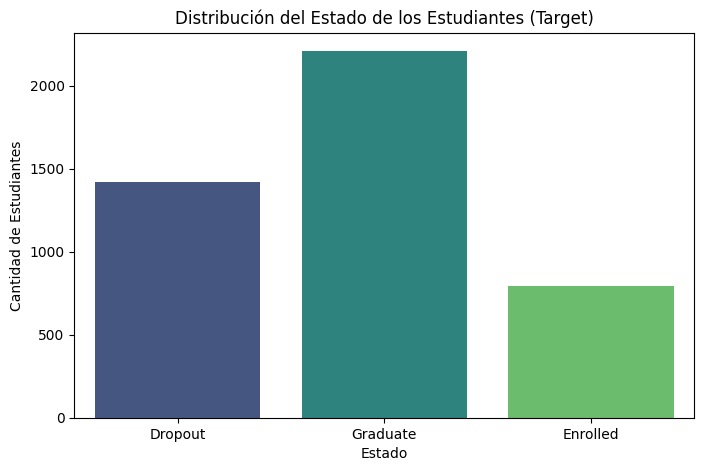

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar estudiantes por categoría
conteo_target = df['Target'].value_counts()
print(conteo_target)

# Crear un gráfico de barras
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Target', palette='viridis')
plt.title('Distribución del Estado de los Estudiantes (Target)')
plt.xlabel('Estado')
plt.ylabel('Cantidad de Estudiantes')
plt.show()


Tarea 3: Distribución de la Edad al momento de Matricularse
Vamos a analizar cómo se distribuye la edad de los estudiantes al ingresar a la institución (Age at enrollment) para entender el perfil demográfico de nuestro conjunto de datos.

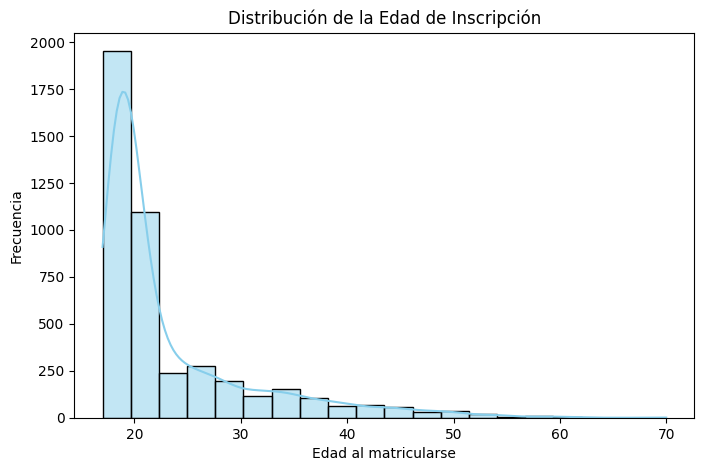

In [ ]:
# Crear un histograma de las edades
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age at enrollment', bins=20, kde=True, color='skyblue')
plt.title('Distribución de la Edad de Inscripción')
plt.xlabel('Edad al matricularse')
plt.ylabel('Frecuencia')
plt.show()


Tarea 4: Relación entre Becas y Estado del Estudiante
En este análisis queremos descubrir si el hecho de ser poseedor de una beca (Scholarship holder) tiene un impacto en si el estudiante abandona, se gradúa o sigue matriculado.



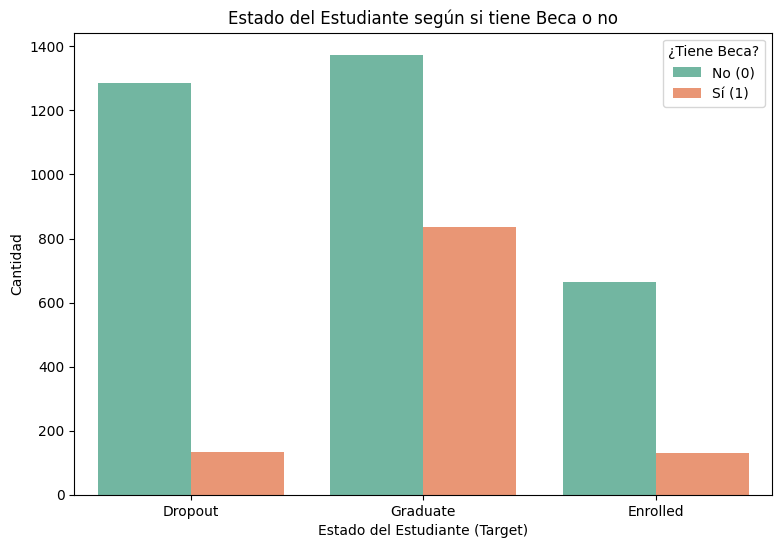

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico de barras agrupadas
plt.figure(figsize=(9, 6))
sns.countplot(data=df, x='Target', hue='Scholarship holder', palette='Set2')

# Ponerle títulos y etiquetas para que se entienda fácil
plt.title('Estado del Estudiante según si tiene Beca o no')
plt.xlabel('Estado del Estudiante (Target)')
plt.ylabel('Cantidad')
plt.legend(title='¿Tiene Beca?', labels=['No (0)', 'Sí (1)'])
plt.show()


**2. Definición del Problema de Clasificación**
El problema que abordaremos consiste en predecir el estado académico final de estudiantes universitarios.

Dado que nuestra variable objetivo (Target) tiene **3 posibles resultados** categóricos **("Dropout" / Abandono, "Graduate" / Graduado, y "Enrolled" / Sigue matriculado)**, estamos frente a un problema de **Clasificación Multiclase.**

Utilizaremos **características demográficas, socioeconómicas y del rendimiento académico previo de los estudiantes** (recopiladas al momento de su inscripción) para entrenar modelos de Machine Learning. **El objetivo final o caso de uso de este modelo sería poder identificar tempranamente a los estudiantes con alto riesgo de deserción (Dropout) para poder ofrecerles apoyo a tiempo.**

------------------------------------

**3. Diseño del Experimento**
Para resolver el problema de clasificación planteado, ejecutaremos el siguiente experimento:

**Dataset a utilizar:** Predict Students' Dropout and Academic Success (UCI Machine Learning Repository). Cuenta con 4424 registros, 36 variables predictoras (features) y 1 variable objetivo. Como validamos en el EDA, el dataset está limpio y no requiere imputación de valores nulos.

**Tipo de Entrenamiento:** Dividiremos los datos utilizando un enfoque de Hold-out (Train/Test Split). Siguiendo las recomendaciones de los creadores del dataset, usaremos un 80% de los datos para entrenamiento (Train) y reservaremos el 20% restante para pruebas (Test).

**Definición de Modelos:** Para poder comparar rendimientos, entrenaremos tres algoritmos distintos de clasificación:

**Regresión Logística:** Como modelo base (baseline) rápido y fácil de interpretar.
**Bosque Aleatorio (Random Forest):** Un modelo más complejo (ensamble) que suele tener alta precisión y nos dirá qué variables son las más importantes.
Métricas de Comparación: Al ser un problema multiclase evaluaremos los modelos usando:

**Accuracy (Exactitud):** Para medir el porcentaje total de aciertos.
Precisión, Recall y F1-Score: Especialmente nos fijaremos en el Recall de la clase "Dropout", ya que es el error que más nos cuesta en la vida real (no detectar a alguien que va a abandonar).
Matriz de Confusión: Para entender visualmente entre qué clases se están confundiendo más nuestros modelos.

---------------------------------

**Definición de Modelos**: Para poder comparar rendimientos, entrenaremos tres algoritmos de distintas familias:
**Regresión Logística:** Como modelo base (baseline) rápido y estadísticamente interpretable.
**Máquinas de Vectores de Soporte (SVM):** Un modelo robusto basado en fronteras de decisión y márgenes, que nos obligará a estandarizar los datos previamente para obtener un buen rendimiento.
**Bosque Aleatorio (Random Forest):** Un modelo complejo de tipo ensamble (múltiples árboles) que maneja muy bien relaciones no lineales y nos dirá qué variables son las más importantes.

analizamos principalmente el recall,